# Exploratory analysis - 363 days of YouTube listening

Everything here reads from `data/taste.db`, built by
`python -m taste_engine.parse_takeout`. Nothing in this notebook calls
the YouTube API, so it costs no quota to re-run.

The questions it answers, in order:

1. What is actually in the export, and what is broken about it?
2. How concentrated is the listening?
3. Which of the watched videos are music, and how confidently do we know?
4. What structure does the library have?
5. Does the model beat the most-played baseline?

In [1]:
import sys, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, '../src')

import pandas as pd
import matplotlib.pyplot as plt

from taste_engine.db import connect
from taste_engine import classify, score, embed, evaluate, config

plt.rcParams.update({'figure.figsize': (9, 3.4), 'axes.grid': True,
                     'grid.alpha': .25, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 9})
conn = connect()
print('db:', config.DB_PATH)

db: /mnt/c/Users/uditk/Projects/taste-engine/data/taste.db


## 1. What is in the export

In [2]:
counts = {t: conn.execute(f'SELECT COUNT(*) FROM {t}').fetchone()[0]
          for t in ('plays', 'playlists', 'playlist_tracks', 'library_songs')}
counts['unique videos'] = conn.execute(
    'SELECT COUNT(DISTINCT video_id) FROM plays').fetchone()[0]
counts['plays w/o channel'] = conn.execute(
    'SELECT COUNT(*) FROM plays WHERE channel IS NULL').fetchone()[0]
lo, hi = conn.execute('SELECT MIN(watched_at), MAX(watched_at) FROM plays').fetchone()
print(pd.Series(counts).to_string())
print(f'\nrange: {lo[:10]} -> {hi[:10]}')

plays                40619
playlists               58
playlist_tracks      11475
library_songs          239
unique videos        30440
plays w/o channel     6649

range: 2025-09-14 -> 2026-09-13


### The 12-month wall

Auto-delete is on, so the history starts abruptly on 2025-09-14 and this
dataset will never grow backwards. Any 'listening over time' chart has a
hard left edge that is an artefact of Google's retention policy, not of
the user's behaviour.

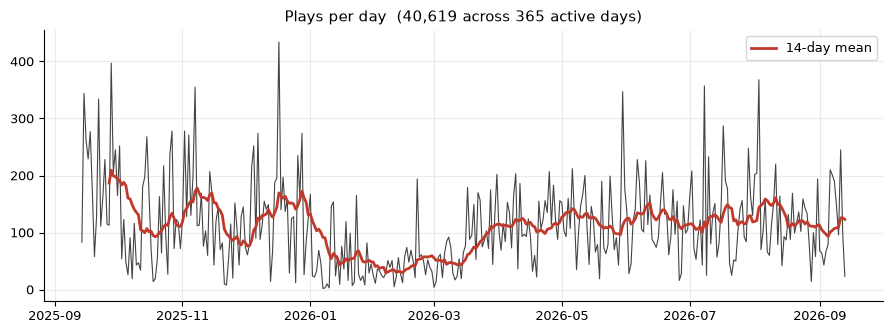

In [3]:
plays = pd.read_sql('SELECT video_id, watched_at, source FROM plays', conn)
plays['day'] = pd.to_datetime(plays.watched_at, format='ISO8601', utc=True).dt.date
daily = plays.groupby('day').size()

ax = daily.plot(lw=.8, color='#444')
daily.rolling(14).mean().plot(ax=ax, lw=2, color='#c0392b', label='14-day mean')
ax.set_title(f'Plays per day  ({daily.sum():,} across {len(daily)} active days)')
ax.set_xlabel(''); ax.legend(); plt.tight_layout(); plt.show()

### Playlist timestamps are not a signal

53 of 58 playlists claim to have been created on one of two days in March
2026 - a bulk import, not user behaviour - and the export restamped almost
every `updated_at` to the export date. Playlist recency is therefore
unusable, which is asserted in `tests/test_dataset_facts.py` so nothing
downstream starts relying on it.

In [4]:
pl = pd.read_sql('SELECT title, created_at, updated_at FROM playlists', conn)
print('created_at:'); print(pl.created_at.str[:10].value_counts().to_string())
print('\nupdated_at:'); print(pl.updated_at.str[:10].value_counts().head(3).to_string())
dupes = pl.title.value_counts()
print(f'\nduplicate playlist titles: {(dupes > 1).sum()} '
      f'(e.g. {dupes.index[0]!r} x{dupes.iloc[0]})')

created_at:
created_at
2026-03-11    39
2026-03-17    14
2026-09-13     2
2026-08-18     1
2026-03-07     1
2022-09-15     1

updated_at:
updated_at
2026-09-13    56
2026-08-18     1
2026-08-11     1

duplicate playlist titles: 9 (e.g. 'Jim' x3)


## 2. How concentrated is the listening?

2,858 music tracks, 9,134 plays
  top  20 tracks =  9.6% of plays
  top  50 tracks = 17.6% of plays
  top 100 tracks = 27.9% of plays
  top 500 tracks = 63.1% of plays
  played exactly once: 60.0% of tracks


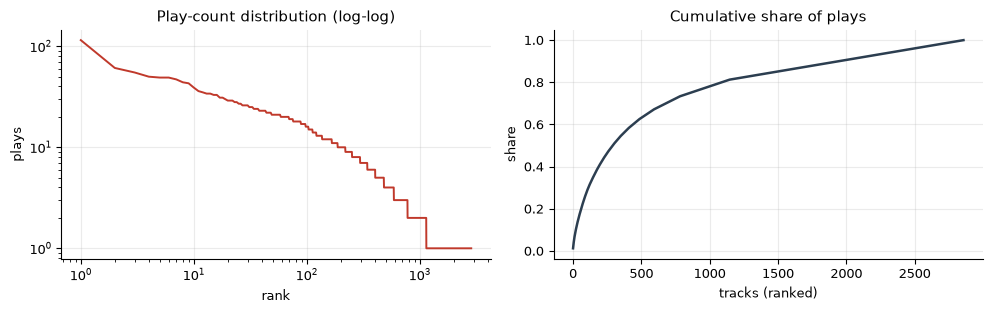

In [5]:
tracks = score.scored_tracks(conn)
pc = tracks.play_count.sort_values(ascending=False).reset_index(drop=True)
print(f'{len(pc):,} music tracks, {pc.sum():,} plays')
for n in (20, 50, 100, 500):
    print(f'  top {n:>3} tracks = {pc.head(n).sum() / pc.sum():>5.1%} of plays')
print(f'  played exactly once: {(pc == 1).mean():.1%} of tracks')

fig, (a, b) = plt.subplots(1, 2, figsize=(10, 3.2))
a.loglog(range(1, len(pc) + 1), pc.values, lw=1.4, color='#c0392b')
a.set(title='Play-count distribution (log-log)', xlabel='rank', ylabel='plays')
b.plot(pc.cumsum().values / pc.sum(), lw=1.8, color='#2c3e50')
b.set(title='Cumulative share of plays', xlabel='tracks (ranked)', ylabel='share')
plt.tight_layout(); plt.show()

A 60% one-play rate is why `log1p` matters. Raw counts would let a handful
of obsessively repeated tracks dominate every playlist; `log1p` keeps the
gap meaningful without letting it crush the tail.

## 3. Which videos are music?

Five signals, none of which costs API quota. The union is the training set.

                     signal  videos  plays  pct_videos  pct_plays
Channel ends with '- Topic'    2336   6387         7.7       15.7
    Channel contains 'VEVO'     371   2225         1.2        5.5
Played on music.youtube.com    2472   7342         8.1       18.1
Video appears in a playlist     845   3549         2.8        8.7
  Video in YT Music library     134   1055         0.4        2.6
         Union (any signal)    2858   9134         9.4       22.5


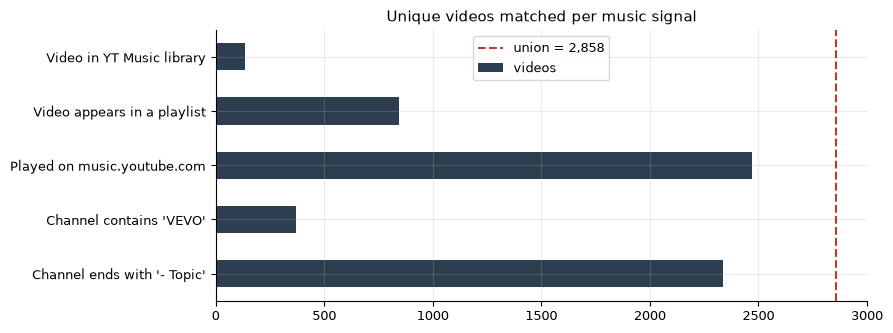

In [6]:
cov = classify.signal_coverage(conn)
print(cov.to_string(index=False))

ax = cov.iloc[:-1].plot.barh(x='signal', y='videos', legend=False,
                             color='#2c3e50')
ax.axvline(cov.videos.iloc[-1], color='#c0392b', ls='--',
           label=f'union = {cov.videos.iloc[-1]:,}')
ax.set(title='Unique videos matched per music signal', ylabel='')
ax.legend(); plt.tight_layout(); plt.show()

The signals overlap heavily: they sum to 6,158 but the union is only 2,858.
They also share a blind spot - an artist-owned channel with no `- Topic` or
`VEVO` marker is invisible to all five. `videos.list` fixes that for 609
units; see `taste_engine.resolve`.

In [7]:
if classify.has_metadata(conn):
    t = classify.comparison_table(conn)
    print(f"agreement   {t['agreement_rate']:.1%}")
    print(f"precision   {t['heuristic_precision']:.1%}")
    print(f"recall      {t['heuristic_recall']:.1%}")
    print(t['confusion'])
else:
    print('No API metadata cached - heuristic labels only.')
    print('Run: python -m taste_engine.resolve   (609 units)')

No API metadata cached - heuristic labels only.
Run: python -m taste_engine.resolve   (609 units)


## 4. What structure does the library have?

In [8]:
clustered = embed.cluster_tracks(tracks)
summary = embed.cluster_summary(clustered)
n = int(clustered.loc[clustered.cluster >= 0, 'cluster'].nunique())
noise = (clustered.cluster == -1).mean()
print(f'{n} clusters, {noise:.1%} outliers')
summary[summary.cluster >= 0].head(15)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 4436.68it/s]

38 clusters, 39.6% outliers


,cluster,name,tracks,plays,mean_score,top_track
0,37,Kanye West,9,21,0.048,Stronger
1,36,Kendrick Lamar,21,97,0.797,luther
2,35,Lil Baby / Lil Peep / Chris Brown,56,247,0.642,Ready
3,34,Drake,138,526,0.611,Drake - Whisper My Name
4,33,Young Thug,12,29,0.310,B*tches Gone Tell (feat. Meek Mill)
5,32,Lil Uzi Vert,11,70,0.912,20 Min
6,31,Arctic Monkeys / Ellie Goulding / Anna Marx,33,46,0.188,always been you
7,30,Travis Scott,141,975,0.810,Travis Scott - MY EYES (Official Audio)
8,29,Future,118,440,0.611,All to Myself
9,28,21 Savage,51,251,0.713,21 Savage - a lot (Official Video) ft. J. Co


Two honest caveats.

**These are artist clusters, not moods.** The embedding text is
`"{title} - {artist}"`, so MiniLM keys heavily on the artist name. Genre
is a decent proxy for mood, but a track that sounds nothing like the rest
of an artist's catalogue still lands with them.

**40% of tracks are outliers.** Given 60% of tracks were played exactly
once, that is closer to honest than alarming - HDBSCAN is refusing to
invent a mood for a one-off listen, which is exactly why it was chosen
over KMeans.

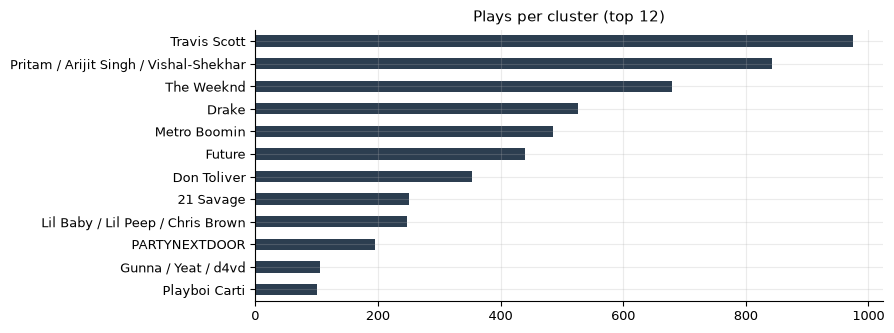

In [9]:
top = summary[summary.cluster >= 0].nlargest(12, 'plays')
ax = top.plot.barh(x='name', y='plays', legend=False, color='#2c3e50')
ax.set(title='Plays per cluster (top 12)', ylabel='')
ax.invert_yaxis(); plt.tight_layout(); plt.show()

## 5. Does it beat the baseline?

Temporal hold-out: train strictly before the split, test after. The
baseline is 'recommend the most-played tracks', which for repeat
consumption is strong, not a strawman.

In [10]:
report = evaluate.evaluate(conn, test_days=config.EVAL_TEST_DAYS)
print(f"train < {report['split_date']} <= test ({report['test_days']}d), "
      f"k={report['k']}, half-life={report['half_life']:.0f}d")
report['results']

train < 2026-06-01 <= test (30d), k=50, half-life=30d


,strategy,hits,precision@50,ndcg@50,spearman
1,score,48,0.96,0.5302,0.4249
0,most_played,43,0.86,0.5271,0.4948
2,recency,23,0.46,0.3459,0.2717
3,cluster_diverse,33,0.66,0.3109,NaN


### Why not precision@20 over the full remaining window?

Because it saturates. Run exactly as the brief specified, the *baseline*
scores 1.00 - a track played 50 times in nine months is certain to recur
in the next three. A metric that cannot go up cannot rank anything.

In [11]:
sat = evaluate.evaluate(conn, k=20, test_days=None)
print(f"precision@20, full 105-day window - saturated: {sat['saturated']}")
sat['results'][['strategy', 'hits', 'precision@20', 'ndcg@20']]

precision@20, full 105-day window - saturated: True


,strategy,hits,precision@20,ndcg@20
1,score,20,1.00,0.5561
0,most_played,20,1.00,0.5303
2,recency,17,0.85,0.3940
3,cluster_diverse,18,0.90,0.3388


### One split is one sample

The half-life is chosen on *consistency across splits*, not on the single
best number. 7 days scores higher on average but loses at one boundary;
30 days never loses.

In [12]:
detail, summary_r = evaluate.robustness(conn)
print(summary_r.to_string(index=False, float_format=lambda v: f'{v:.4f}'))
print('\nper-split detail, half-life 30:')
detail[detail.half_life == 30][['split', 'test_tracks', 'base_ndcg',
                                'score_ndcg', 'base_precision',
                                'score_precision', 'win']]

 half_life  splits  wins  mean_lift  worst_lift  mean_precision  base_precision
         7       6     5     0.0646     -0.0912          0.7833          0.7367
        30       6     6     0.0586      0.0034          0.8067          0.7367
        90       6     5     0.0668     -0.0048          0.7967          0.7367
       180       6     6     0.0390      0.0043          0.7633          0.7367

per-split detail, half-life 30:


,split,test_tracks,base_ndcg,score_ndcg,base_precision,score_precision,win
1,2026-03-01,858,0.2243,0.2457,0.36,0.36,True
5,2026-04-01,795,0.5617,0.5636,0.86,0.90,True
9,2026-05-01,1012,0.5838,0.6300,0.88,0.92,True
13,2026-06-01,874,0.5271,0.5302,0.86,0.96,True
17,2026-07-01,404,0.3609,0.4134,0.66,0.74,True
21,2026-08-01,723,0.3496,0.3573,0.80,0.96,True


### The result that does not flatter the model

Over the *whole* catalogue, raw play count correlates better with future
play volume than the recency-weighted score does (Spearman 0.49 vs 0.42
at this split). Recency helps at the head of the list, which is what a
50-track playlist draws from, and hurts in the tail. Both are true and
both are reported.

In [13]:
conn.close()
print('done')

done
